# Problem 1: Watershed Segmentation

## Problem

Mục tiêu của bài này là áp dụng **Watershed** để tách các object bị dính nhau hoặc nằm sát nhau trong ảnh.

Các trường hợp phù hợp với Watershed:

- Coins / viên bi / vật thể tròn nằm sát nhau.
- Hạt gạo, tế bào, đá, hạt hoặc các object nhỏ bị chồng lấn nhẹ.
- Mái nhà sát nhau trong ảnh UAV.
- Cây có tán sát nhau trong ảnh từ trên cao.

## Ý tưởng chính

Watershed xem ảnh grayscale như một bản đồ địa hình:

- Pixel tối giống vùng thấp hoặc thung lũng.
- Pixel sáng giống vùng cao hoặc đỉnh núi.
- Quá trình phân vùng giống như nước dâng từ các điểm bắt đầu khác nhau.
- Nơi hai vùng nước gặp nhau sẽ trở thành đường ranh giới giữa các object.

Vì vậy, Watershed không phải là thuật toán chỉ cần đưa ảnh vào là tự tách đẹp ngay. Kết quả phụ thuộc rất nhiều vào cách ta tạo **markers**.

## Marker là gì?

| Thành phần | Ý nghĩa |
| --- | --- |
| `sure foreground` | Vùng chắc chắn là object. |
| `sure background` | Vùng chắc chắn là nền hoặc vùng hỗ trợ xác định nền. |
| `unknown` | Vùng chưa chắc là object hay background, thường nằm quanh biên object. |

Watershed sẽ bắt đầu lan vùng từ các marker chắc chắn, sau đó quyết định ranh giới trong vùng `unknown`.

## Pipeline trong notebook

1. Đọc ảnh và chuẩn bị ảnh hiển thị.
2. Chuyển sang grayscale và làm mượt ảnh.
3. Threshold để tạo mask foreground sơ bộ.
4. Dùng morphology để làm sạch mask.
5. Tạo vùng hỗ trợ background và vùng foreground chắc chắn.
6. Tìm vùng unknown.
7. Tạo marker bằng connected components.
8. Chạy `cv2.watershed()`.
9. Vẽ boundary Watershed lên ảnh gốc.


## Bước 0: Import thư viện và hàm hiển thị

**Bước này là gì?**  
Cell này import các thư viện cần dùng và tạo hàm `show()` để hiển thị ảnh nhanh trong notebook.

**Để làm gì?**  
- `cv2` dùng để xử lý ảnh bằng OpenCV.
- `numpy` dùng để thao tác ma trận ảnh và tạo kernel morphology.
- `matplotlib.pyplot` dùng để hiển thị ảnh trong notebook.

**Hoạt động thế nào?**  
Hàm `show()` tạo một figure nhỏ, gọi `plt.imshow()` để hiển thị ảnh, đặt tiêu đề, tắt trục tọa độ, rồi render hình ra notebook. Với ảnh grayscale, ta truyền thêm `cmap="gray"` để ảnh không bị Matplotlib tô màu giả.


In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show(title, image, cmap=None):
    plt.figure(figsize=(6, 6))
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

## Bước 1: Đọc ảnh, đổi màu, chuyển grayscale và làm mượt

**Bước này là gì?**  
Cell này đọc ảnh đầu vào, chuẩn bị hai phiên bản màu để xử lý/hiển thị, rồi tạo ảnh grayscale và ảnh đã làm mượt.

**Để làm gì?**  
Watershed cần thông tin ảnh gốc khi chạy, nhưng các bước tạo mask thường làm trên ảnh grayscale vì đơn giản hơn. Làm mượt giúp giảm nhiễu nhỏ trước khi threshold.

**Hoạt động thế nào?**  
- `cv2.imread()` đọc ảnh theo định dạng BGR của OpenCV.
- `cv2.cvtColor(..., cv2.COLOR_BGR2RGB)` đổi sang RGB để Matplotlib hiển thị đúng màu.
- `cv2.cvtColor(..., cv2.COLOR_BGR2GRAY)` gom 3 kênh màu thành 1 kênh độ sáng.
- `cv2.GaussianBlur()` làm mượt ảnh bằng Gaussian kernel `(5, 5)`, giúp threshold ít bị ảnh hưởng bởi noise lẻ tẻ.


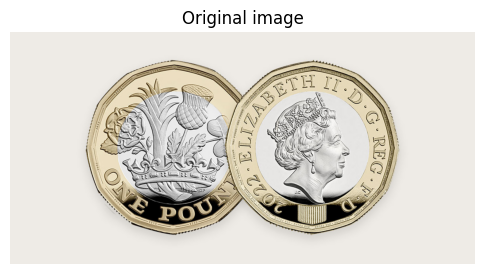

In [65]:
image_path = "dataset/img_04.jpg"

img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Gray and Blur
gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (5, 5), 0)

show("Original image", img_rgb)

## Bước 2: Threshold để tạo mask foreground sơ bộ

**Bước này là gì?**  
Cell này biến ảnh grayscale thành ảnh nhị phân: pixel chỉ còn giá trị `0` hoặc `255`.

**Để làm gì?**  
Ta cần một mask ban đầu để phân biệt vùng có khả năng là object và vùng có khả năng là background. Các bước morphology, distance transform và connected components phía sau đều dựa trên mask này.

**Hoạt động thế nào?**  
`cv2.THRESH_BINARY + cv2.THRESH_OTSU` để Otsu tự tìm ngưỡng tách sáng/tối. Pixel lớn hơn ngưỡng được gán `255`, pixel nhỏ hơn ngưỡng được gán `0`. Với ảnh hiện tại, object sáng hơn nền nên `THRESH_BINARY` là hợp lý; nếu object tối trên nền sáng thì thường cần đổi sang `THRESH_BINARY_INV`.


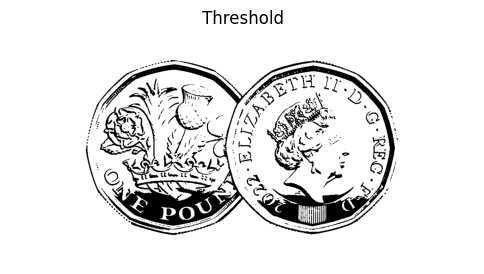

In [66]:
# Threshold để lấy object sơ bộ

ret, thresh = cv2.threshold(
    blur,
    0,
    255,
    cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

show("Threshold", thresh, cmap="gray")

## Bước 3: Morphology Opening để làm sạch mask

**Bước này là gì?**  
Cell này dùng phép morphology `MORPH_OPEN` trên ảnh threshold.

**Để làm gì?**  
Mask threshold thường có noise nhỏ hoặc các điểm trắng lẻ. Nếu giữ nguyên, các điểm này có thể bị tính nhầm thành object riêng khi tạo marker. Opening giúp làm sạch foreground trước khi đi tiếp.

**Hoạt động thế nào?**  
Opening = erosion rồi dilation. Erosion làm mòn vùng trắng, giúp loại bỏ điểm trắng nhỏ. Dilation sau đó nở vùng trắng trở lại để giữ hình dạng object chính. Kernel `3x3` và `iterations=2` quyết định mức độ làm sạch mạnh hay nhẹ.


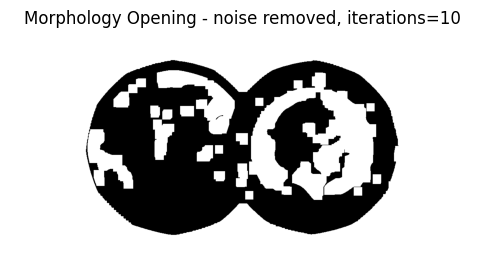

In [67]:
# Morphology để làm sạch mask

kernel = np.ones((3, 3), np.uint8)

iteration = 10

opening = cv2.morphologyEx(
    thresh,
    cv2.MORPH_OPEN,
    kernel,
    iterations=iteration
)

show(f"Morphology Opening - noise removed, iterations={iteration}", opening, cmap="gray")

## Bước 4: Tạo vùng hỗ trợ background bằng dilation

**Bước này là gì?**  
Cell này dùng dilation để nở rộng mask foreground đã được làm sạch.

**Để làm gì?**  
Kết quả dilation được dùng để tạo vùng `unknown` ở bước sau. Vùng nằm giữa foreground chắc chắn và mask đã nở rộng thường là vùng biên chưa rõ object/background, nên ta sẽ để Watershed tự quyết định.

**Hoạt động thế nào?**  
Dilation làm vùng trắng lớn hơn bằng cách mở rộng biên object. Trong template OpenCV, biến này thường được đặt tên là `sure_bg`, nhưng cần hiểu cẩn thận: ở code này nó chủ yếu là mask mở rộng để xác định vùng chưa chắc chắn quanh object. Các pixel nằm ngoài vùng unknown sau này sẽ giữ label background.


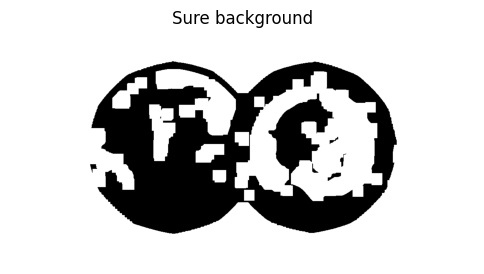

In [68]:
# Tìm sure background

sure_bg = cv2.dilate(
    opening,
    kernel,
    iterations=3
)

show("Sure background", sure_bg, cmap="gray")

## Bước 5: Distance Transform để tìm sure foreground

**Bước này là gì?**  
Cell này tính distance transform trên mask foreground, rồi threshold kết quả đó để lấy phần trung tâm chắc chắn của object.

**Để làm gì?**  
Khi nhiều object dính nhau, mask threshold có thể xem chúng như một khối. Distance transform giúp tìm các vùng lõi nằm sâu bên trong từng object. Những vùng lõi này sẽ trở thành seed/marker foreground cho Watershed.

**Hoạt động thế nào?**  
`cv2.distanceTransform()` tính khoảng cách từ mỗi pixel trắng đến pixel đen gần nhất. Pixel ở gần tâm object thường có giá trị lớn hơn pixel ở biên. Sau đó ta giữ lại các pixel có distance lớn hơn `0.3 * dist_transform.max()`. Ngưỡng này càng cao thì foreground càng chắc nhưng có thể mất object nhỏ; ngưỡng càng thấp thì giữ nhiều vùng hơn nhưng dễ dính hoặc nhiễu.


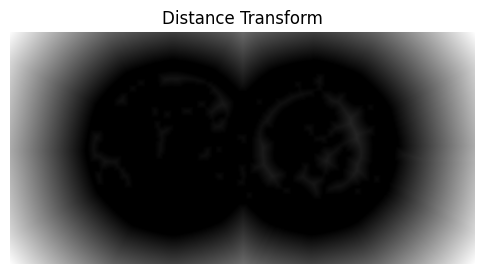

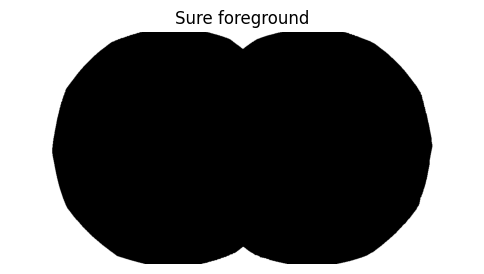

In [69]:
# Tìm sure foreground bằng Distance Transform

dist_transform = cv2.distanceTransform(
    opening,
    cv2.DIST_L2,
    5
)

show("Distance Transform", dist_transform, cmap="gray")

# ====================================

ret, sure_fg = cv2.threshold(
    dist_transform,
    0.3 * dist_transform.max(),
    255,
    0
)

sure_fg = np.uint8(sure_fg)

show("Sure foreground", sure_fg, cmap="gray")

# Hệ số 0.3 là tham số quan trọng. Bạn nên thử: [0.3, 0.4, 0.5, 0.6, 0.7]

## Bước 6: Tìm vùng unknown

**Bước này là gì?**  
Cell này lấy mask mở rộng trừ đi vùng foreground chắc chắn để tìm vùng chưa rõ nhãn.

**Để làm gì?**  
Watershed cần biết vùng nào chắc chắn là object, vùng nào chắc chắn là background, và vùng nào chưa chắc. Vùng `unknown` thường nằm quanh rìa object hoặc giữa các object dính nhau, chính là nơi thuật toán cần quyết định boundary.

**Hoạt động thế nào?**  
`cv2.subtract(sure_bg, sure_fg)` giữ lại những pixel có trong `sure_bg` nhưng không nằm trong `sure_fg`. Nói ngắn gọn: lấy vùng mở rộng quanh object, bỏ phần lõi chắc chắn, phần còn lại là vùng biên chưa chắc chắn.


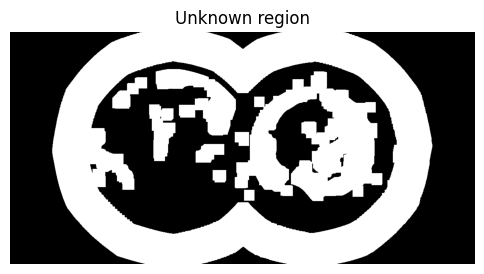

In [70]:
# Tìm unknown region

unknown = cv2.subtract(sure_bg, sure_fg)

show("Unknown region", unknown, cmap="gray")

## Bước 7: Tạo marker image cho Watershed

**Bước này là gì?**  
Cell này biến `sure_fg` thành các nhãn marker bằng connected components, rồi đánh dấu vùng unknown bằng label `0`.

**Để làm gì?**  
`cv2.watershed()` không nhận trực tiếp mask nhị phân đơn giản. Nó cần một ảnh marker, trong đó mỗi vùng chắc chắn có một label số nguyên riêng. Marker tốt thì Watershed mới tách object tốt.

**Hoạt động thế nào?**  
- `cv2.connectedComponents(sure_fg)` tìm các cụm pixel foreground rời nhau.
- Mỗi cụm được gán một số label riêng.
- `markers = markers + 1` đẩy toàn bộ label lên 1 đơn vị để background không còn là `0`.
- `markers[unknown == 255] = 0` đặt vùng chưa rõ thành `0`, vì trong Watershed label `0` nghĩa là vùng cần thuật toán tự xử lý.

Sau bước này: `0` là unknown, `1` là background, còn `2, 3, 4, ...` là các object marker.


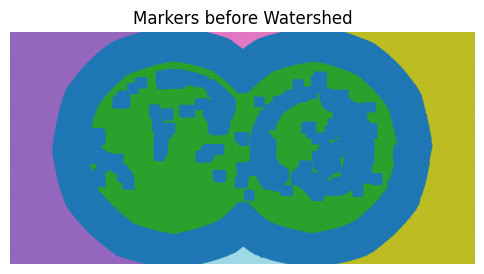

'\n0 = unknown\n1 = background\n2, 3, 4, ... = object markers\n'

In [71]:
# Tạo marker

ret, markers = cv2.connectedComponents(sure_fg)

markers = markers + 1

markers[unknown == 255] = 0

plt.figure(figsize=(6, 6))
plt.imshow(markers, cmap="tab20")
plt.title("Markers before Watershed")
plt.axis("off")
plt.show()

"""
0 = unknown
1 = background
2, 3, 4, ... = object markers
"""

## Bước 8: Chạy Watershed

**Bước này là gì?**  
Cell này gọi `cv2.watershed()` để phân vùng ảnh dựa trên ảnh gốc và marker đã tạo.

**Để làm gì?**  
Đây là bước chính của thuật toán. Watershed sẽ lan các marker object/background vào vùng unknown và tìm đường ranh giới tự nhiên giữa các vùng.

**Hoạt động thế nào?**  
`cv2.watershed(img_bgr, markers.copy())` dùng thông tin gradient/biên trong ảnh màu gốc để quyết định ranh giới. Kết quả trả về là một marker image mới: pixel boundary có label `-1`, background thường là `1`, và object/region có label lớn hơn `1`.


In [72]:
# Chạy Watershed

markers_ws = cv2.watershed(img_bgr, markers.copy())

"""
markers_ws == -1  → boundary do watershed tìm được
markers_ws == 1   → background
markers_ws > 1    → các object/region
"""

'\nmarkers_ws == -1  → boundary do watershed tìm được\nmarkers_ws == 1   → background\nmarkers_ws > 1    → các object/region\n'

## Bước 9: Vẽ boundary Watershed lên ảnh gốc

**Bước này là gì?**  
Cell này tạo ảnh kết quả bằng cách tô màu các pixel boundary lên ảnh gốc.

**Để làm gì?**  
Watershed trả về marker dạng số, không phải ảnh đẹp để xem trực tiếp. Ta cần overlay boundary lên ảnh RGB để đánh giá trực quan thuật toán đã tách object hợp lý chưa.

**Hoạt động thế nào?**  
`markers_ws == -1` chọn các pixel ranh giới do Watershed tìm được. Code gán các pixel đó thành `[255, 0, 0]`, tức màu đỏ trong ảnh RGB. Sau đó `show()` hiển thị ảnh có boundary.


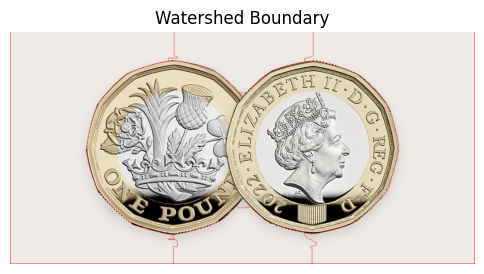

In [73]:
# Vẽ boundary lên ảnh gốc

result = img_rgb.copy()

result[markers_ws == -1] = [255, 0, 0]

show("Watershed Boundary", result)

# Problem 2: Region Splitting and Merging (Phân vùng ảnh bằng Tách và Gộp vùng)

---

## 📌 Giới thiệu tổng quan
Phương pháp **Region Splitting and Merging (Tách và Gộp vùng)** là một kỹ thuật phân vùng ảnh dựa trên tính chất vùng (region-based segmentation). Thay vì tìm biên (edge-based) như Sobel/Canny hay tìm ngưỡng toàn cục (thresholding), phương pháp này tiếp cận theo hai hướng bổ trợ cho nhau:

1. **Region Splitting (Tách vùng Top-Down):** Xuất phát từ toàn bộ ảnh, nếu một vùng chưa đồng nhất (non-homogeneous), ta tiếp tục chia nhỏ vùng đó thành 4 vùng con theo cấu trúc cây tứ phân (**Quadtree**) cho đến khi các vùng con đạt độ đồng nhất hoặc đạt kích thước nhỏ nhất cho phép.
2. **Region Merging (Gộp vùng Bottom-Up):** Sau khi tách, ảnh bị xé lẻ thành rất nhiều block nhỏ. Các block lân cận nhau (adjacent) và có đặc trưng tương đồng (ví dụ: cường độ sáng trung bình gần bằng nhau) sẽ được gộp lại thành các vùng lớn hơn mang ý nghĩa của vật thể (object).

---

## ⚙️ Tổng quan Pipeline thực hiện
Toàn bộ quy trình xử lý trong Problem 2 được chia thành các giai đoạn rõ ràng:

```
[ Ảnh gốc Grayscale ]
         │
         ▼
 ┌──────────────────────────────────────────────┐
 │ Giai đoạn 1: REGION SPLITTING (Tách vùng)    │
 └──────────────────────────────────────────────┘
         │  • Kiểm tra tính đồng nhất (Homogeneity Check: std < threshold)
         │  • Đệ quy chia 4 vùng con (Quadtree Splitting)
         ▼
 [ Danh sách các blocks nhỏ đồng nhất ]
         │
         ▼
 ┌──────────────────────────────────────────────┐
 │ Giai đoạn 2: REGION MERGING (Gộp vùng)       │
 └──────────────────────────────────────────────┘
         │  • Trích xuất đặc trưng vùng (Tính Mean intensity)
         │  • Tìm kiếm các vùng lân cận (Adjacency Graph / Label Map)
         │  • Gộp vùng bằng cấu trúc Union-Find nếu |Mean_A - Mean_B| < merge_threshold
         ▼
 [ Phân vùng hoàn chỉnh (Segmented Regions) ]
         │
         ▼
 ┌──────────────────────────────────────────────┐
 │ Giai đoạn 3: VISUALIZATION (Trực quan hóa)   │
 └──────────────────────────────────────────────┘
            • Gán màu ngẫu nhiên cho từng vùng gộp
            • Overlay lên ảnh gốc để đánh giá kết quả
```

## 🔍 Chi tiết về Region Splitting (Tách vùng bằng Quadtree)

**Nguyên lý hoạt động:**
- Bắt đầu với một khối lớn tương ứng toàn bộ bức ảnh.
- Kiểm tra tiêu chí đồng nhất $P(R)$: Ở bài này ta dùng độ lệch chuẩn (Standard Deviation - `np.std`). Nếu $\text{std}(R) < \text{threshold}$, vùng $R$ được coi là đồng nhất phẳng (chẳng hạn nền trời, bức tường).
- Nếu vùng **không đồng nhất** ($\text{std}(R) \ge \text{threshold}$), ta chia vùng $R$ thành 4 góc phần tư (quadrants) bằng nhau và lặp lại quá trình kiểm tra cho từng vùng con.

**Ý nghĩa thực tế:**
- **Vùng nền phẳng (Flat background):** Ít biến thiên sáng $\rightarrow$ std nhỏ $\rightarrow$ Giữ nguyên block lớn.
- **Vùng biên object / Texture phức tạp:** Biến thiên sáng mạnh $\rightarrow$ std lớn $\rightarrow$ Bị chia cắt thành các block rất nhỏ để bám sát chi tiết.

### Bước 1: Import thư viện và xây dựng hàm hiển thị ảnh (`showme`)

**Bước này làm gì?**  
Cell này import các thư viện xử lý ảnh cốt lõi (`cv2`, `numpy`, `matplotlib`) và định nghĩa hàm `showme()` để vẽ nhiều ảnh trên cùng một hàng ngang một cách thuận tiện.

**Mục đích**  
Giúp code gọn gàng, tái sử dụng hàm hiển thị cho các bước trực quan hóa kết quả phía sau mà không cần viết lại cấu trúc `plt.subplot`.

**Hoạt động thế nào?**  
Hàm nhận vào danh sách ảnh `img` và danh sách tiêu đề `title`, tự động xác định kích thước figure (`figsize`) dựa vào số lượng ảnh (`core_num`) và duyệt qua từng ảnh để hiển thị bằng `matplotlib`.

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- `estimate = 5`: Kích thước ước tính cho mỗi sub-figure (chiều rộng figure = `core_num * estimate`). Nếu muốn ảnh hiển thị to hoặc nhỏ hơn trên notebook, bạn có thể chỉnh tham số `estimate` này.

In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def showme(img=[], title=[], cmap=None):
    core_num = len(img)
    estimate = 5

    plt.figure(figsize=(core_num*estimate, estimate))

    for i in range(1, core_num + 1):
        plt.subplot(1, core_num, i)
        plt.imshow(img[i-1], cmap='gray')
        plt.title(title[i-1])
        plt.axis('off')

    plt.show()

### Bước 2: Đọc dữ liệu ảnh và chuyển đổi định dạng màu

**Bước này làm gì?**  
Cell này đọc ảnh đầu vào từ thư mục `dataset/pro2_01.jpg`, chuyển đổi hệ màu từ BGR (mặc định của OpenCV) sang RGB (để hiển thị đúng màu trên Matplotlib) và sang Grayscale (ảnh xám 1 kênh màu).

**Mục đích**  
Thuật toán Region Splitting & Merging trong bài thực hành này phân tích trên cường độ sáng (intensity) đơn kênh, do đó ảnh Grayscale (`img_gray`) là input chính. Ảnh RGB (`img_rgb`) được dùng để đối chiếu và overlay kết quả cuối cùng.

**Hoạt động thế nào?**  
Sử dụng `cv2.imread()` để đọc ảnh, sau đó dùng `cv2.cvtColor()` với các cờ `COLOR_BGR2RGB` và `COLOR_BGR2GRAY`.

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- `image_path = "dataset/pro2_01.jpg"`: Đường dẫn đến ảnh thử nghiệm. Bạn có thể thay đổi đường dẫn này để thử nghiệm thuật toán trên các bức ảnh khác trong dataset.

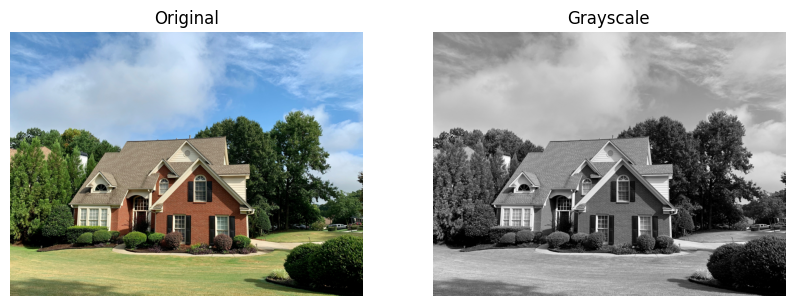

In [6]:
image_path = "dataset/pro2_01.jpg"

img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

img = [img_rgb, img_gray]
til = ["Original", "Grayscale"]

showme(img, til)

### Bước 3: Xây dựng tiêu chí kiểm tra độ đồng nhất (`is_homogeneous`)

**Bước này làm gì?**  
Cell này định nghĩa hàm `is_homogeneous(region, threshold)` để kiểm tra xem một vùng ảnh (patch/block) có đủ đồng nhất về cường độ sáng hay không.

**Mục đích**  
Đây là "trái tim" của điều kiện dừng trong thuật toán Region Splitting. Nó quyết định một vùng sẽ được giữ nguyên hay tiếp tục bị xé nhỏ thành 4 vùng con.

**Hoạt động thế nào?**  
Tính độ lệch chuẩn (Standard Deviation) của tất cả pixel trong vùng bằng `np.std(region)`. Nếu giá trị này nhỏ hơn `threshold`, hàm trả về `True` (đồng nhất), ngược lại trả về `False`.

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- `threshold = 10` (Ngưỡng đồng nhất): 
  - **Threshold thấp (nghiêm ngặt):** Yêu cầu vùng phải cực kỳ phẳng mới được coi là đồng nhất $\rightarrow$ ảnh bị chia thành rất nhiều block nhỏ.
  - **Threshold cao (dễ dãi):** Dễ chấp nhận vùng đồng nhất $\rightarrow$ dừng chia sớm, giữ lại các khối lớn nhưng có thể làm mất chi tiết biên của object.

In [7]:
def is_homogeneous(region, threshold=10):
    std = np.std(region)
    return std < threshold

"""
threshold thấp → yêu cầu đồng nhất nghiêm ngặt hơn → chia nhiều hơn
threshold cao  → dễ chấp nhận vùng hơn → chia ít hơn
"""

'\nthreshold thấp → yêu cầu đồng nhất nghiêm ngặt hơn → chia nhiều hơn\nthreshold cao  → dễ chấp nhận vùng hơn → chia ít hơn\n'

### Bước 4: Viết hàm đệ quy Region Splitting (`region_splitting`)

**Bước này làm gì?**  
Cell này cài đặt thuật toán chia vùng theo cấu trúc cây tứ phân (Quadtree Splitting) dưới dạng một hàm đệ quy.

**Mục đích**  
Tự động duyệt qua toàn bộ ảnh, kiểm tra từng vùng và tiếp tục chia nhỏ các vùng phức tạp cho đến khi toàn bộ ảnh được phủ bởi các block đồng nhất hoặc đạt kích thước tối thiểu.

**Hoạt động thế nào?**  
Hàm kiểm tra 2 điều kiện dừng (Base cases):
1. Nếu kích thước vùng chiều rộng `w` hoặc chiều cao `h` $\le$ `min_size`: Dừng chia và lưu tọa độ `(x, y, w, h)` vào danh sách `regions`.
2. Nếu vùng thỏa mãn tiêu chí `is_homogeneous(region, threshold)`: Dừng chia và lưu tọa độ `(x, y, w, h)`.

Nếu không thỏa mãn cả 2 điều kiện trên, vùng được chia làm 4 góc phần tư bằng nhau (`w2 = w // 2`, `h2 = h // 2`) và gọi đệ quy `region_splitting` cho 4 vùng con này.

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- `threshold = 10`: Ngưỡng truyền vào cho hàm kiểm tra đồng nhất.
- `min_size = 8`: Kích thước cạnh tối thiểu của một block (pixel). Giúp ngăn thuật toán chia quá nhỏ tới mức từng pixel đơn lẻ (1x1), tránh bùng nổ số lượng vùng và giảm tải tính toán.

In [8]:
# Viết hàm Region Splitting

def region_splitting(image, x, y, w, h, threshold=10, min_size=8, regions=None):
    if regions is None:
        regions = []

    region = image[y:y+h, x:x+w]

    # Điều kiện dừng 1: vùng quá nhỏ
    if w <= min_size or h <= min_size:
        regions.append((x, y, w, h))
        return regions

    # Điều kiện dừng 2: vùng đủ đồng nhất
    if is_homogeneous(region, threshold):
        regions.append((x, y, w, h))
        return regions

    # Nếu chưa đồng nhất thì chia thành 4 phần
    w2 = w // 2
    h2 = h // 2

    region_splitting(image, x,      y,      w2,     h2,     threshold, min_size, regions)
    region_splitting(image, x+w2,   y,      w-w2,   h2,     threshold, min_size, regions)
    region_splitting(image, x,      y+h2,   w2,     h-h2,   threshold, min_size, regions)
    region_splitting(image, x+w2,   y+h2,   w-w2,   h-h2,   threshold, min_size, regions)

    return regions

### Bước 5: Thực thi Region Splitting trên ảnh Grayscale

**Bước này làm gì?**  
Cell này gọi hàm `region_splitting()` vừa xây dựng trên toàn bộ ảnh `img_gray` ban đầu với tọa độ góc trên bên trái `(0, 0)` và kích thước `(w, h)`.

**Mục đích**  
Chạy thực tế thuật toán để thu về danh sách `regions` chứa tọa độ và kích thước của tất cả các khối (blocks) sau khi tách.

**Hoạt động thế nào?**  
Lấy `h, w = img_gray.shape`, truyền vào hàm đệ quy và in ra tổng số lượng vùng (`len(regions)`) thu được.

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- Bạn có thể thử nghiệm tuning bộ đôi `threshold=10` và `min_size=8` tại đây để quan sát sự thay đổi về số lượng vùng (`Number of regions`). Ví dụ nếu tăng `threshold=15`, số lượng vùng thu được sẽ giảm đi đáng kể.

In [9]:
# Chạy Region Splitting

h, w = img_gray.shape

regions = region_splitting(
    img_gray,
    x=0,
    y=0,
    w=w,
    h=h,
    threshold=10,
    min_size=8
)

print("Number of regions:", len(regions))

Number of regions: 141079


### Bước 6: Trực quan hóa đường viền các block sau khi Tách vùng

**Bước này làm gì?**  
Cell này vẽ khung hình chữ nhật (bounding box) cho từng vùng trong danh sách `regions` đè lên ảnh màu RGB gốc.

**Mục đích**  
Giúp quan sát trực quan sự phân bố của cấu trúc Quadtree: các vùng nền phẳng sẽ là các hình chữ nhật to, trong khi các khu vực biên hoặc có nhiều chi tiết phức tạp sẽ dày đặc các hình chữ nhật nhỏ.

**Hoạt động thế nào?**  
Tạo một bản sao của ảnh gốc (`result = img_rgb.copy()`), lặp qua từng bộ `(x, y, w, h)` trong `regions` và dùng `cv2.rectangle()` vẽ viền màu đỏ `(255, 0, 0)` với độ dày 1 pixel. Sau đó hiển thị bằng `showme()`.

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- Màu sắc `(255, 0, 0)` (Đỏ) và độ dày nét vẽ `1`: Có thể chỉnh sửa nếu muốn đường viền nổi bật hoặc dễ nhìn hơn trên màu nền của ảnh.

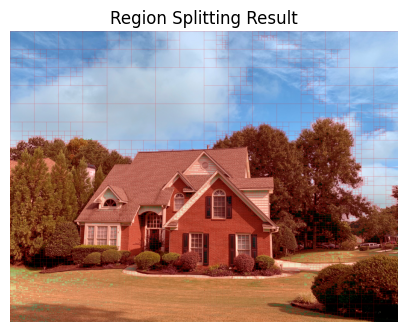

In [10]:
result = img_rgb.copy()

for x, y, w, h in regions:
    cv2.rectangle(
        result,
        (x, y),
        (x + w, y + h),
        (255, 0, 0),
        1
    )

showme([result], ["Region Splitting Result"])

### Bước 7: Trực quan hóa phân vùng bằng cường độ sáng trung bình (Mean Intensity Block)

**Bước này làm gì?**  
Cell này tạo một ảnh mới `segmented` nơi mỗi block từ kết quả splitting được tô bằng một màu xám đồng nhất chính là giá trị trung bình (mean) của các pixel trong block đó.

**Mục đích**  
Đánh giá chất lượng của giai đoạn Region Splitting. Ảnh tạo ra trông giống như một bức ảnh làm mờ dạng khối (pixelated/mosaic), cho thấy ảnh đã được biểu diễn bởi các vùng đồng nhất ra sao trước khi bước vào giai đoạn gộp (merging).

**Hoạt động thế nào?**  
Tạo ma trận rỗng `np.zeros_like(img_gray)`. Duyệt qua từng vùng `(x, y, w, h)`, cắt vùng tương ứng trên `img_gray`, tính `np.mean(region)` và gán giá trị trung bình đó cho toàn bộ block trên ảnh `segmented`.

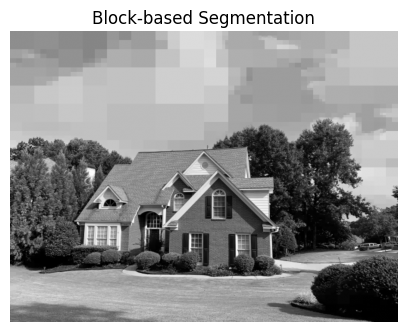

In [11]:
# Tạo ảnh segmentation dạng block màu trung bình

segmented = np.zeros_like(img_gray)

for x, y, w, h in regions:
    region = img_gray[y:y+h, x:x+w]
    mean_value = int(np.mean(region))
    segmented[y:y+h, x:x+w] = mean_value

showme([segmented], ["Block-based Segmentation"])

# Giai đoạn 2: Region Merging (Gộp vùng)

---

## 📌 Giới thiệu & Mục tiêu
Sau giai đoạn **Region Splitting**, ảnh đã được chia thành hàng nghìn block nhỏ (quadtree blocks) đồng nhất bên trong. Tuy nhiên, một object thực tế (ví dụ: cái áo, khuôn mặt, bầu trời) lại bị cắt vụn thành rất nhiều block nằm sát cạnh nhau. 

**Region Merging** có nhiệm vụ kết nối và gộp các block nhỏ lân cận lại với nhau để khôi phục lại các vùng lớn mang ý nghĩa ngữ nghĩa hoàn chỉnh (semantic objects).

---

## 💡 Nguyên lý & Tiêu chí Gộp vùng

Để hai block $A$ và $B$ được gộp lại với nhau thành một vùng duy nhất, chúng phải thỏa mãn đồng thời **2 điều kiện**:
1. **Điều kiện không gian (Adjacency):** Hai block phải nằm sát cạnh nhau (có tiếp xúc ranh giới với nhau).
2. **Điều kiện đặc trưng (Similarity):** Đặc trưng cường độ sáng của hai block phải tương đồng. Ở bài này ta so sánh giá trị cường độ sáng trung bình (mean intensity):
   $$\big| \text{Mean}_A - \text{Mean}_B \big| < \text{merge\_threshold}$$

---

## 🛠️ Cấu trúc dữ liệu Union-Find (Disjoint-Set)
Để gộp hàng nghìn region một cách hiệu quả mà không bị lặp hay xung đột, bài thực hành sử dụng cấu trúc dữ liệu **Union-Find (Disjoint Set Union - DSU)**:
- Mỗi block ban đầu là một tập hợp độc lập (cha của nó là chính nó).
- Khi phát hiện 2 block kề nhau thỏa mãn điều kiện ngưỡng chênh lệch mean, thao tác `union(A, B)` sẽ hợp nhất hai tập hợp lại.
- Cuối cùng, thao tác `find(x)` giúp gom tất cả các block có cùng "tổ tiên" (root) vào chung một nhóm (group/segment hoàn chỉnh).

### Bước 8: Trích xuất đặc trưng cho từng vùng (`compute_region_features`)

**Bước này làm gì?**  
Cell này duyệt qua danh sách các block `regions` từ bước splitting và tính toán giá trị trung bình cường độ sáng (`mean`) cho mỗi block.

**Mục đích**  
Chuẩn bị gói dữ liệu đặc trưng (id, bounding box, mean intensity) cho từng region để phục vụ việc so sánh độ tương đồng ở bước Merging.

**Hoạt động thế nào?**  
Với mỗi vùng `(x, y, w, h)`, hàm cắt patch trên ảnh xám `gray`, dùng `np.mean(patch)` để tính mean và lưu vào danh sách dictionary `features` chứa ID, tọa độ và giá trị mean.

In [12]:
# Tính mean cho từng region
def compute_region_features(gray, regions):
    features = []

    for idx, (x, y, w, h) in enumerate(regions):
        patch = gray[y:y+h, x:x+w]
        mean_value = np.mean(patch)

        features.append({
            "id": idx,
            "bbox": (x, y, w, h),
            "mean": mean_value
        })

    return features

### Bước 9: Xây dựng lớp cấu trúc dữ liệu Union-Find

**Bước này làm gì?**  
Cell này định nghĩa class `UnionFind` với hai phương thức cốt lõi là `find(x)` (tìm gốc đại diện với kỹ thuật tối ưu path compression) và `union(a, b)` (gộp hai nhóm).

**Mục đích**  
Cung cấp công cụ quản lý các tập hợp rời rạc (disjoint sets), giúp việc gộp các regions kề nhau đạt độ phức tạp thời gian gần như tuyến tính $O(N \alpha(N))$, tối ưu và nhanh chóng cho hàng nghìn blocks.

**Hoạt động thế nào?**  
Khởi tạo `self.parent` chứa mảng chỉ số. Khi `union(a, b)` được gọi, gốc của `b` sẽ được trỏ về gốc của `a`. Khi gọi `find(x)`, đệ quy tìm gốc và đè lại parent để rút ngắn đường đi (kỹ thuật tối ưu nén đường đi - path compression).

In [13]:
# Union-Find để gộp region
# Đây là cấu trúc giúp gộp nhiều region lại thành cùng một nhóm.

class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))

    def find(self, x):
        if self.parent[x] != x:
            self.parent[x] = self.find(self.parent[x])
        return self.parent[x]

    def union(self, a, b):
        root_a = self.find(a)
        root_b = self.find(b)

        if root_a != root_b:
            self.parent[root_b] = root_a

### Bước 10 (Minh họa khái niệm): Hàm gộp vùng cơ bản (`region_merging`)

**Bước này làm gì?**  
Cell này minh họa ý tưởng gộp vùng bằng hai vòng lặp lồng nhau $O(N^2)$ duyệt qua tất cả các cặp region $(i, j)$ để kiểm tra kề nhau (`are_adjacent`) và kiểm tra chênh lệch mean.

**Mục đích**  
Hiển thị rõ ràng logic lý thuyết của Region Merging giúp người học dễ hiểu bước kiểm tra điều kiện gộp.

**💡 Lưu ý quan trọng**  
Cell code này là **mã minh họa ý tưởng (conceptual code)**. Hàm `are_adjacent(bbox_i, bbox_j)` chưa được định nghĩa ở đây vì việc kiểm tra 2 hình chữ nhật kề nhau bằng vòng lặp thuần túy rất chậm. Thuật toán chạy thực tế tối ưu hơn sẽ được xây dựng ở các bước 11, 12, 13 ngay bên dưới bằng kỹ thuật ma trận nhãn (Label Map).

**⚙️ Tham số:**  
- `merge_threshold = 15`: Ngưỡng chênh lệch mean tối đa cho phép để gộp 2 vùng.

In [14]:
# Hàm merge region
def region_merging(gray, regions, merge_threshold=15):
    features = compute_region_features(gray, regions)

    n = len(features)
    uf = UnionFind(n)

    for i in range(n):
        for j in range(i + 1, n):
            bbox_i = features[i]["bbox"]
            bbox_j = features[j]["bbox"]

            mean_i = features[i]["mean"]
            mean_j = features[j]["mean"]

            if are_adjacent(bbox_i, bbox_j):
                if abs(mean_i - mean_j) < merge_threshold:
                    uf.union(i, j)

    # Gom region theo group id
    groups = {}

    for i in range(n):
        root = uf.find(i)

        if root not in groups:
            groups[root] = []

        groups[root].append(i)

    return groups

### Bước 11 (Tối ưu hóa): Tạo ma trận nhãn (`build_label_map`)

**Bước này làm gì?**  
Cell này tạo một ma trận 2D có kích thước bằng ảnh gốc, trong đó mỗi pixel được gán giá trị bằng chỉ số ID (`idx`) của region chứa pixel đó.

**Mục đích**  
Thay vì kiểm tra va chạm tọa độ bounding box một cách phức tạp, ma trận nhãn (`label_map`) chuyển bài toán tìm vùng kề nhau thành việc kiểm tra các pixel nằm cạnh nhau trên ma trận, giúp tăng tốc độ xử lý lên nhiều lần.

**Hoạt động thế nào?**  
Khởi tạo ma trận toàn `-1` bằng `np.full()`. Duyệt qua danh sách `regions`, gán ID của vùng cho toàn bộ block tương ứng trên ma trận bằng kỹ thuật slicing `label_map[y:y+rh, x:x+rw] = idx`.

In [15]:
def build_label_map(gray, regions):
    h, w = gray.shape
    label_map = np.full((h, w), -1, dtype=np.int32)

    for idx, (x, y, rw, rh) in enumerate(regions):
        label_map[y:y+rh, x:x+rw] = idx

    return label_map

### Bước 12 (Tối ưu hóa): Tìm kiếm các cặp vùng lân cận cực nhanh (`get_adjacent_pairs`)

**Bước này làm gì?**  
Cell này trích xuất toàn bộ danh sách các cặp ID region nằm sát cạnh nhau từ ma trận nhãn `label_map`.

**Mục đích**  
Loại bỏ triệt để vòng lặp cặp $O(N^2)$. Ta chỉ cần lấy các cặp region thực sự có tiếp xúc ranh giới theo chiều ngang hoặc chiều dọc để kiểm tra điều kiện gộp.

**Hoạt động thế nào?**  
- **Dọc theo chiều ngang:** So sánh ma trận dịch trái `label_map[:, :-1]` và dịch phải `label_map[:, 1:]`. Lấy ra các vị trí có ID khác nhau và không phải `-1`.
- **Dọc theo chiều dọc:** So sánh ma trận dịch trên `label_map[:-1, :]` và dịch dưới `label_map[1:, :]`. Lấy ra các cặp ID khác nhau.

Dùng cấu trúc `set()` và chuẩn hóa cặp `(min(a,b), max(a,b))` để loại bỏ các cặp trùng lặp.

In [16]:
def get_adjacent_pairs(label_map):
    pairs = set()

    left = label_map[:, :-1]
    right = label_map[:, 1:]

    mask = (left != right) & (left != -1) & (right != -1)

    for a, b in zip(left[mask], right[mask]):
        pairs.add((int(min(a, b)), int(max(a, b))))

    top = label_map[:-1, :]
    bottom = label_map[1:, :]

    mask = (top != bottom) & (top != -1) & (bottom != -1)

    for a, b in zip(top[mask], bottom[mask]):
        pairs.add((int(min(a, b)), int(max(a, b))))

    return pairs

### Bước 13: Cài đặt thuật toán gộp vùng tốc độ cao (`region_merging_fast`)

**Bước này làm gì?**  
Cell này kết hợp các hàm `compute_region_features`, `build_label_map`, `get_adjacent_pairs` và cấu trúc `UnionFind` thành một quy trình gộp vùng hoàn chỉnh và tối ưu hóa.

**Mục đích**  
Hàm chính thức dùng để thực thi Region Merging một cách nhanh chóng trên dữ liệu thực tế.

**Hoạt động thế nào?**  
1. Trích xuất đặc trưng và tìm danh sách các cặp region lân cận.
2. Khởi tạo `UnionFind` cho $N$ regions.
3. Duyệt qua từng cặp region lân cận `(i, j)`: Nếu `abs(mean_i - mean_j) < merge_threshold`, tiến hành `uf.union(i, j)`.
4. Gom nhóm các region có cùng gốc (`uf.find(i)`) vào từ điển `groups`. Mỗi từ điển biểu diễn một object/vùng lớn đã gộp.

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- `merge_threshold = 15`: Ngưỡng quyết định việc gộp. Tham số này rất quan trọng để cân chỉnh kết quả phân vùng cuối cùng.

In [17]:
def region_merging_fast(gray, regions, merge_threshold=15):
    features = compute_region_features(gray, regions)
    label_map = build_label_map(gray, regions)
    adjacent_pairs = get_adjacent_pairs(label_map)

    uf = UnionFind(len(regions))

    for i, j in adjacent_pairs:
        mean_i = features[i]["mean"]
        mean_j = features[j]["mean"]

        if abs(mean_i - mean_j) < merge_threshold:
            uf.union(i, j)

    groups = {}

    for i in range(len(regions)):
        root = uf.find(i)

        if root not in groups:
            groups[root] = []

        groups[root].append(i)

    return groups

### Bước 14: Thực thi Region Merging và đánh giá số lượng vùng

**Bước này làm gì?**  
Cell này gọi hàm `region_merging_fast()` trên ảnh `img_gray` và danh sách `regions` thu được từ bước Splitting, sau đó in ra sự thay đổi về số lượng vùng trước và sau khi gộp.

**Mục đích**  
Chạy thuật toán và kiểm chứng hiệu quả giảm thiểu số lượng vùng rác, hợp nhất các block nhỏ thành các vùng ngữ nghĩa lớn hơn.

**Hoạt động thế nào?**  
Truyền tham số vào hàm và in kết quả ra màn hình bằng `print()`.

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- `merge_threshold = 15`: **Đây là tham số quan trọng nhất cần tinh chỉnh (tuning parameter) của bước Merging.**
  - Nếu tăng lên (ví dụ `25`, `30`): Thuật toán gộp mạnh tay hơn, số lượng vùng sau gộp (`after merging`) giảm mạnh, các vùng nối liền nhau hơn nhưng dễ bị gộp nhầm object vào background (under-segmentation).
  - Nếu giảm xuống (ví dụ `5`, `10`): Chỉ các block cực kỳ giống nhau mới được gộp, số lượng vùng còn lại nhiều (over-segmentation).

In [19]:
# Chạy merging
groups = region_merging_fast(
    img_gray,
    regions,
    merge_threshold=15 # Change
)

print("Number of regions before merging:", len(regions))
print("Number of regions after merging:", len(groups))

Number of regions before merging: 141079
Number of regions after merging: 15770


### Bước 15: Viết hàm tạo ảnh màu trực quan hóa cho vùng gộp (`visualize_merged_regions`)

**Bước này làm gì?**  
Cell này định nghĩa hàm sinh ra một ảnh màu RGB, trong đó mỗi nhóm vùng đã gộp (group) được tô bằng một màu sắc ngẫu nhiên (random color) duy nhất.

**Mục đích**  
Giúp con người dễ dàng phân biệt các vùng segment khác nhau bằng mắt thường sau quá trình gộp.

**Hoạt động thế nào?**  
Tạo ảnh đen rỗng bằng `np.zeros()`. Dùng `np.random.default_rng(42)` tạo bộ sinh số ngẫu nhiên với seed cố định (để màu không bị đổi lung tung mỗi lần chạy lại cell). Duyệt qua từng `group_id`, sinh một màu RGB ngẫu nhiên và tô màu đó cho tất cả các block thuộc group đó.

**⚙️ Tham số có thể chỉnh sửa:**  
- Seed `42`: Nếu bạn muốn đổi dải màu ngẫu nhiên khác cho đẹp mắt hơn, bạn có thể thay đổi số `42` thành bất kỳ số nguyên nào khác (ví dụ `0`, `99`, `2024`).

In [20]:
# Tạo ảnh màu random cho từng merged region
def visualize_merged_regions(gray, regions, groups):
    h, w = gray.shape

    output = np.zeros((h, w, 3), dtype=np.uint8)

    rng = np.random.default_rng(42)

    for group_id, region_indices in groups.items():
        color = rng.integers(0, 255, size=3, dtype=np.uint8)

        for idx in region_indices:
            x, y, rw, rh = regions[idx]
            output[y:y+rh, x:x+rw] = color

    return output

### Bước 16: Hiển thị kết quả trực quan hóa màu sắc các vùng đã gộp

**Bước này làm gì?**  
Cell này gọi hàm `visualize_merged_regions()` để sinh ảnh phân vùng màu (`merged_color`) và đặt hiển thị cạnh ảnh gốc bằng `showme()`.

**Mục đích**  
Quan sát trực quan kết quả phân vùng tách biệt các object/khu vực trên ảnh dưới dạng các mảng màu rực rỡ.

**Hoạt động thế nào?**  
Truyền `img_gray`, `regions`, `groups` vào hàm và gọi `showme([img_rgb, merged_color], ...)` để hiển thị song song.

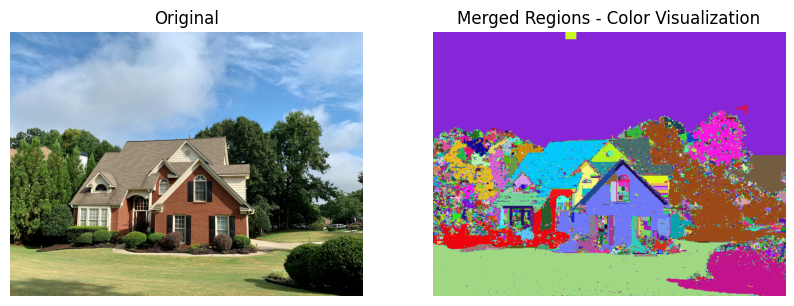

In [23]:
merged_color = visualize_merged_regions(img_gray, regions, groups)

# show(, merged_color, figsize=(8, 8))

showme([img_rgb, merged_color], ["Original", "Merged Regions - Color Visualization"])

### Bước 17: Viết hàm trộn màu phân vùng đè lên ảnh gốc (`overlay_segmentation`)

**Bước này làm gì?**  
Cell này định nghĩa hàm pha trộn (blend/overlay) ảnh màu phân vùng (`segmentation_color`) lên ảnh gốc RGB (`img_rgb`) theo một độ trong suốt (`alpha`).

**Mục đích**  
Khi xem ảnh phân vùng màu thuần túy, ta khó xác định ranh giới màu đó tương ứng chính xác với chi tiết nào trên ảnh gốc. Việc overlay giúp ta kiểm chứng đường biên phân vùng bám sát vật thể thực tế đến mức nào.

**Hoạt động thế nào?**  
Sử dụng hàm `cv2.addWeighted(img1, w1, img2, w2, gamma)` theo công thức:
$$\text{Overlay} = \text{img\_rgb} \times (1 - \alpha) + \text{segmentation\_color} \times \alpha$$

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- `alpha`: Độ trong suốt của lớp màu phân vùng (dao động trong khoảng từ `0.0` đến `1.0`).

In [24]:
# Overlay màu lên ảnh gốc cho dễ nhìn
def overlay_segmentation(img_rgb, segmentation_color, alpha=0.5):
    overlay = cv2.addWeighted(
        img_rgb,
        1 - alpha,
        segmentation_color,
        alpha,
        0
    )

    return overlay

### Bước 18: Hiển thị kết quả Overlay cuối cùng

**Bước này làm gì?**  
Cell này gọi hàm `overlay_segmentation()` với `alpha = 0.45` và hiển thị đồng thời 3 ảnh: Ảnh gốc, Ảnh phân vùng màu, và Ảnh overlay.

**Mục đích**  
Kết luận và đánh giá toàn diện tổng thể pipeline Region Splitting and Merging trên bức ảnh thử nghiệm.

**Hoạt động thế nào?**  
Tạo ảnh `overlay` và hiển thị bằng `showme()`.

**⚙️ Tham số có thể chỉnh sửa:**  
- `alpha = 0.45`: Bạn có thể điều chỉnh tham số này (ví dụ `0.3` để thấy rõ ảnh gốc hơn, hoặc `0.7` để lớp màu phân vùng đậm và rõ nét hơn).

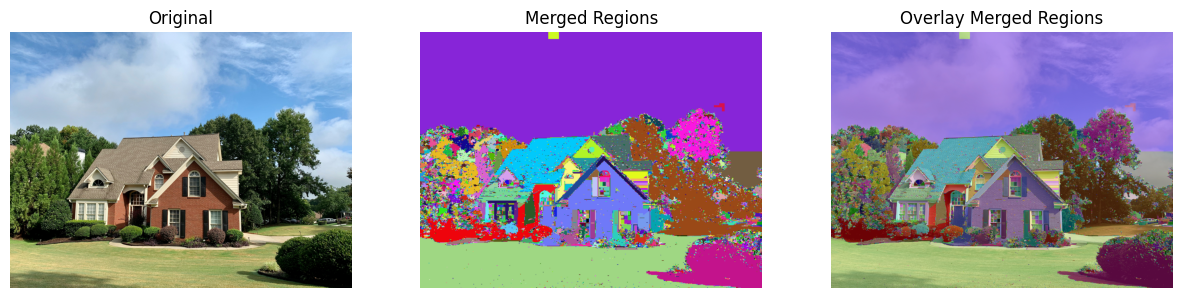

In [27]:
overlay = overlay_segmentation(img_rgb, merged_color, alpha=0.45)

showme([img_rgb, merged_color, overlay], ["Original", "Merged Regions", "Overlay Merged Regions"])

# Problem 3: Graph-based Segmentation

## Giới thiệu

Graph-based Segmentation là một phương pháp phân đoạn ảnh dựa trên lý thuyết đồ thị. Thay vì xem ảnh chỉ là một ma trận pixel, phương pháp này biểu diễn ảnh như một graph:

- Mỗi pixel hoặc vùng nhỏ được xem như một node.
- Mối quan hệ giữa các pixel/vùng lân cận được xem như edge.
- Trọng số của edge thể hiện mức độ khác nhau giữa hai pixel/vùng, ví dụ khác biệt về màu sắc, intensity hoặc texture.

Ý tưởng chính là: các pixel/vùng lân cận có đặc trưng giống nhau sẽ được gộp vào cùng một segment, còn các pixel/vùng khác nhau nhiều sẽ được tách ra thành các segment khác nhau.

## Mục tiêu của bài thực hành

Trong bài thực hành này, ta áp dụng thuật toán Graph-based Segmentation để chia ảnh thành nhiều segment khác nhau. Mỗi segment là một vùng gồm các pixel tương đối giống nhau và có liên kết không gian với nhau.

Bài thực hành tập trung vào:

1. Chạy thuật toán Graph-based Segmentation trên ảnh màu.
2. Quan sát label map sau khi phân đoạn.
3. Visualize mỗi segment bằng một màu khác nhau.
4. Hiển thị boundary của các segment trên ảnh gốc.
5. Thử thay đổi các tham số như `scale`, `sigma`, và `min_size` để quan sát ảnh hưởng đến kết quả.

## Ý nghĩa các tham số chính

- `scale`: điều khiển mức độ gộp vùng. Giá trị nhỏ thường tạo nhiều segment nhỏ, giá trị lớn thường tạo ít segment và vùng lớn hơn.
- `sigma`: mức làm mượt ảnh trước khi segmentation. Giá trị lớn giúp giảm nhiễu nhưng có thể làm mất chi tiết nhỏ.
- `min_size`: kích thước nhỏ nhất của một segment. Các segment nhỏ hơn giá trị này sẽ được gộp vào segment lân cận.

## Kết quả mong đợi

Sau khi chạy thuật toán, ta thu được một label map, trong đó mỗi pixel được gán một nhãn segment. Các pixel có cùng nhãn thuộc cùng một vùng. Kết quả sẽ được visualize theo hai cách:

- Mỗi segment được tô bằng một màu khác nhau để dễ phân biệt.
- Boundary của các segment được vẽ lên ảnh gốc để quan sát đường phân chia vùng.

Lưu ý rằng Graph-based Segmentation không nhất thiết tạo ra object hoàn chỉnh như con người hiểu. Nó chủ yếu nhóm các vùng có màu sắc hoặc đặc trưng gần giống nhau, vì vậy một object có thể bị chia thành nhiều segment, hoặc các vùng khác object nhưng màu gần giống nhau có thể bị gộp lại.

### Bước 1: Import các thư viện và mô-đun cần thiết

**Bước này làm gì?**  
Cell này import các thư viện xử lý ảnh nền tảng (`cv2`, `numpy`, `matplotlib`), các hàm phân vùng từ `scikit-image` (`felzenszwalb`, `label2rgb`), và hàm tiện ích hiển thị ảnh `showme` từ gói `utils`.

**Mục đích**  
Chuẩn bị đầy đủ các công cụ để thực hiện Graph-based Segmentation (theo thuật toán Felzenszwalb-Huttenlocher) và trực quan hóa kết quả.

**Hoạt động thế nào?**  
- `felzenszwalb`: Hàm cài đặt sẵn thuật toán Graph-based Segmentation hiệu quả cao của scikit-image.
- `label2rgb`: Hàm chuyển đổi ma trận nhãn (label map) thành ảnh màu RGB để con người dễ quan sát.
- `showme`: Hàm hiển thị nhiều ảnh ngang hàng được thiết kế trong gói `utils`.

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.segmentation import felzenszwalb
from skimage.color import label2rgb
from utils.visual import showme

### Bước 2: Đọc dữ liệu ảnh và chuyển sang hệ màu RGB

**Bước này làm gì?**  
Cell này đọc ảnh thử nghiệm từ thư mục `dataset/pro3_01.jpg`, chuyển hệ màu từ BGR sang RGB và hiển thị ảnh gốc lên Notebook bằng `showme()`.

**Mục đích**  
Thuật toán Graph-based Segmentation (`felzenszwalb`) trong scikit-image hoạt động trực tiếp trên ảnh màu RGB để tính toán độ tương đồng/khác biệt màu sắc giữa các pixel kề nhau (biểu diễn dưới dạng trọng số cạnh trên đồ thị). Do đó, việc chuyển đúng hệ màu RGB là bước chuẩn bị bắt buộc.

**⚙️ Tham số có thể chỉnh sửa:**  
- `image_path = "dataset/pro3_01.jpg"`: Bạn có thể thử thay bằng đường dẫn đến ảnh khác trong dataset để kiểm chứng khả năng phân đoạn trên nhiều loại ảnh.

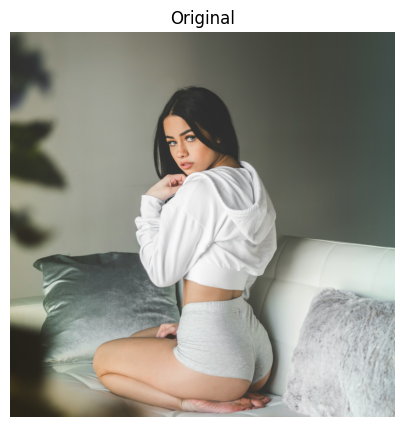

In [3]:
image_path = "dataset/pro3_01.jpg"

img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

showme([img_rgb], ["Original"])

### Bước 3: Thực thi thuật toán Graph-based Segmentation (`felzenszwalb`)

**Bước này làm gì?**  
Cell này gọi hàm `felzenszwalb()` trên ảnh màu `img_rgb` để thực hiện phân đoạn ảnh dựa trên lý thuyết đồ thị, sau đó in ra tổng số lượng segment (vùng) thu được.

**Mục đích**  
Chia ảnh thành các vùng rời rạc dựa trên mối liên kết không gian và sự tương đồng về màu sắc. Output trả về là một ma trận nhãn 2D (`segments`), nơi mỗi pixel mang một số nguyên chỉ định ID của vùng chứa nó.

**Hoạt động thế nào?**  
Thuật toán xem mỗi pixel là một đỉnh (node), cạnh nối liền kề có trọng số là độ lệch màu. Thuật toán duyệt qua các cạnh theo thứ tự tăng dần và gộp 2 vùng nếu trọng số cạnh nhỏ hơn ngưỡng khả năng chịu đựng của vùng (được điều khiển bởi `scale`). Sau đó gộp tiếp các vùng có kích thước nhỏ hơn `min_size`.

**⚙️ Tham số cần tinh chỉnh (Tuning Parameters):**  
- `scale = 100`: Tỷ lệ quan sát (mức độ gộp vùng). 
  - **Tăng `scale` (ví dụ 300, 500):** Thuật toán gộp mạnh tay hơn $\rightarrow$ tạo ra **ít segment hơn**, các vùng lớn hơn.
  - **Giảm `scale` (ví dụ 20, 50):** Nhạy cảm với chi tiết $\rightarrow$ tạo ra **rất nhiều segment nhỏ**.
- `sigma = 0.5`: Độ lệch chuẩn của bộ lọc Gaussian dùng để làm mượt ảnh trước khi phân đoạn giúp giảm nhiễu (noise).
- `min_size = 50`: Kích thước tối thiểu (số pixel) của một segment. Các vùng có số pixel $< 50$ sẽ tự động bị gộp ép vào vùng lân cận có độ tương đồng cao nhất.

In [4]:
# Chạy Graph-based Segmentation

segments = felzenszwalb(
    img_rgb,
    scale=100,
    sigma=0.5,
    min_size=50
)

print("Number of segments:", len(np.unique(segments)))

"""
Ý nghĩa output:

segments là label map
mỗi pixel có một label
pixel cùng label = cùng segment

Ví dụ:

segments[y, x] = 3  → pixel này thuộc region số 3
segments[y, x] = 8  → pixel này thuộc region số 8
"""

Number of segments: 6735


'\nÝ nghĩa output:\n\nsegments là label map\nmỗi pixel có một label\npixel cùng label = cùng segment\n\nVí dụ:\n\nsegments[y, x] = 3  → pixel này thuộc region số 3\nsegments[y, x] = 8  → pixel này thuộc region số 8\n'

### Bước 4: Trực quan hóa kết quả phân vùng bằng màu trung bình (`label2rgb`)

**Bước này làm gì?**  
Cell này sử dụng hàm `label2rgb()` để biến ma trận nhãn `segments` thành một bức ảnh màu hoàn chỉnh (`seg_color`), sau đó đặt hiển thị song song với ảnh gốc bằng `showme()`.

**Mục đích**  
Giúp chúng ta quan sát rõ ràng các ranh giới phân vùng bằng mắt thường. Do ma trận `segments` chỉ chứa các con số ID (0, 1, 2...), việc chuyển sang màu hiển thị là cần thiết để đánh giá chất lượng segment.

**Hoạt động thế nào?**  
Với tham số `kind="avg"`, hàm sẽ tính màu sắc trung bình của tất cả pixel thuộc cùng 1 segment trên ảnh gốc `img_rgb`, rồi tô màu trung bình đó cho toàn bộ segment trên ảnh kết quả.

**⚙️ Tham số cần lưu ý / Có thể chỉnh sửa:**  
- `kind = "avg"`: Tô mỗi vùng bằng màu trung bình thực tế của vùng đó trên ảnh gốc (tạo hiệu ứng ảnh làm mờ dạng tranh vẽ mosaic). Bạn có thể đổi thành `kind = "overlay"` để phủ lớp màu ngẫu nhiên bán trong suốt lên ảnh gốc.

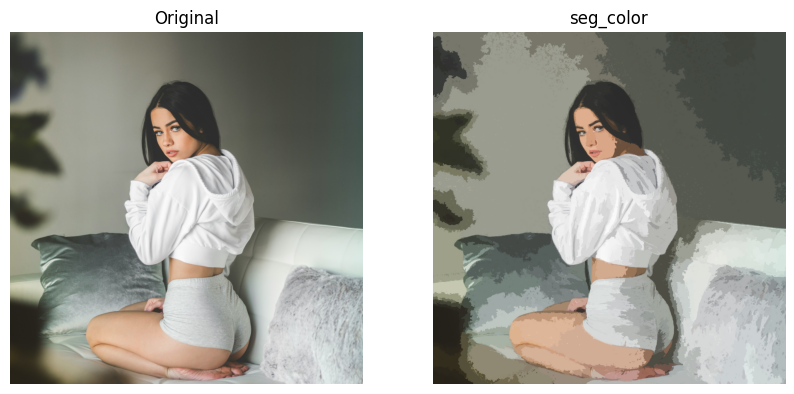

In [5]:
# Visualize mỗi segment bằng màu khác nhau

seg_color = label2rgb(
    segments,
    image=img_rgb,
    kind="avg",
    bg_label=-1
)

showme([img_rgb, seg_color], ["Original", "seg_color"])

# Problem 4: Probabilistic Aggregation

## Giới thiệu

Probabilistic Aggregation là một phương pháp gộp vùng dựa trên xác suất. Thay vì quyết định gộp hai vùng bằng một điều kiện cứng như:

$$
|\mu_i - \mu_j| < T
$$

phương pháp này đánh giá mức độ tin cậy rằng hai region lân cận có nên thuộc cùng một segment hay không.

Nói cách khác, với hai region lân cận $R_i$ và $R_j$, ta không chỉ hỏi:

> Hai vùng này có giống nhau không?

mà hỏi:

> Xác suất hai vùng này nên được gộp là bao nhiêu?

Nếu xác suất gộp đủ cao, hai region sẽ được merge.

---

## Gray-level Similarity

Một cue đơn giản là độ tương đồng về mức xám hoặc intensity trung bình giữa hai region.

Gọi:

- $R_i, R_j$ là hai region lân cận.
- $\mu_i, \mu_j$ là intensity trung bình của hai region.
- $d_g(R_i, R_j)$ là độ khác biệt gray-level.

Ta có thể định nghĩa:

$$
d_g(R_i, R_j) = |\mu_i - \mu_j|
$$

Độ khác biệt càng nhỏ thì hai region càng giống nhau. Có thể chuyển độ khác biệt này thành xác suất tương đồng:

$$
P_g(R_i, R_j) = \exp\left(-\frac{d_g(R_i, R_j)}{\sigma_g}\right)
$$

Trong đó:

- $P_g(R_i, R_j)$ là xác suất tương đồng theo intensity.
- $\sigma_g$ điều khiển độ nhạy với khác biệt intensity.
- $d_g$ càng nhỏ thì $P_g$ càng gần 1.
- $d_g$ càng lớn thì $P_g$ càng gần 0.

---

## Texture Similarity

Ngoài intensity, hai region cũng có thể được so sánh bằng texture.

Gọi:

- $h_i$ là histogram texture của region $R_i$.
- $h_j$ là histogram texture của region $R_j$.
- $d_t(R_i, R_j)$ là độ khác biệt texture giữa hai region.

Một cách đơn giản để đo khác biệt texture là dùng khoảng cách histogram:

$$
d_t(R_i, R_j) = \sum_{k=1}^{K} |h_i(k) - h_j(k)|
$$

Sau đó chuyển thành xác suất tương đồng texture:

$$
P_t(R_i, R_j) = \exp\left(-\frac{d_t(R_i, R_j)}{\sigma_t}\right)
$$

Trong đó:

- $P_t(R_i, R_j)$ là xác suất tương đồng theo texture.
- $\sigma_t$ điều khiển độ nhạy với khác biệt texture.
- Texture càng giống nhau thì $d_t$ càng nhỏ và $P_t$ càng cao.

---

## Merge Probability

Ta có thể kết hợp nhiều cue để tạo xác suất gộp cuối cùng:

$$
P_{\text{merge}}(R_i, R_j)
=
\alpha P_g(R_i, R_j)
+
(1 - \alpha) P_t(R_i, R_j)
$$

Trong đó:

- $P_{\text{merge}}(R_i, R_j)$ là xác suất hai region nên được gộp.
- $P_g$ là xác suất tương đồng gray-level.
- $P_t$ là xác suất tương đồng texture.
- $\alpha$ là trọng số cân bằng giữa intensity và texture.

Nếu $\alpha$ lớn, thuật toán ưu tiên intensity nhiều hơn.  
Nếu $\alpha$ nhỏ, thuật toán ưu tiên texture nhiều hơn.

---

## Quyết định merge

Sau khi có xác suất gộp, ta dùng một threshold $T_p$ để quyết định:

$$
\text{Merge}(R_i, R_j)
=
\begin{cases}
1, & \text{if } P_{\text{merge}}(R_i, R_j) > T_p \\
0, & \text{otherwise}
\end{cases}
$$

Trong đó:

- $T_p$ là ngưỡng xác suất.
- Nếu $P_{\text{merge}}$ lớn hơn $T_p$, hai region được gộp.
- Nếu $P_{\text{merge}}$ nhỏ hơn hoặc bằng $T_p$, hai region được giữ tách riêng.

---

## Ý nghĩa

Probabilistic Aggregation có thể được xem là phiên bản mềm hơn của Region Merging. Thay vì chỉ dùng một điều kiện cứng dựa trên intensity, phương pháp này cho phép kết hợp nhiều cue như gray-level similarity và texture similarity.

Kết quả cuối cùng vẫn là các segment/region sau khi gộp, nhưng cơ chế quyết định linh hoạt hơn:

- Hai vùng có intensity hơi khác nhưng texture giống nhau vẫn có thể được merge.
- Hai vùng có intensity gần nhau nhưng texture khác nhau có thể không được merge.
- Việc merge được quyết định bằng xác suất thay vì một rule cố định duy nhất.